In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2

H, W = 4096, 850
intensity = np.fromfile("/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training Data/CN029_FK_24_M/OS/6-0D/4/Horizontal/Intensity.bin", dtype=np.float64)
# print("intensity size:", intensity.size, intensity.dtype, intensity.min(), intensity.max())
# intensity= intensity[:H*W].reshape(W, H).T
intensity= intensity[:H*W]
intensity= intensity.reshape(W, H).T

low, high = np.percentile(intensity, (1, 99))
intensity_clipped = np.clip(intensity, low, high)
intensity1 = (intensity_clipped - low) / (high - low)
intensity1 = (intensity1[:1400, :]*255).astype(np.uint8)

print('min:', intensity1.min(), 'max:', intensity1.max())
intensity2 = (intensity1 - np.min(intensity1)) / (np.max(intensity1) - np.min(intensity1))
print('min:', intensity2.min(), 'max:', intensity2.max())
cv2.imwrite("/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/intensity2.png", (intensity1 * 255).astype(np.uint8))

plt.subplot(1,3,1)
plt.title("Intensity ")
plt.imshow(intensity1 , cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Intensity ")
plt.imshow(intensity2, cmap="gray")
# plt.colorbar()
plt.axis("off")

# plt.subplot(1,3,3)
# plt.title("Segmentation Mask")
# plt.imshow(interns, cmap="tab20")  # colorful labels
# # plt.axis("off")

plt.tight_layout()
plt.show()

ValueError: cannot reshape array of size 1740801 into shape (850,4096)

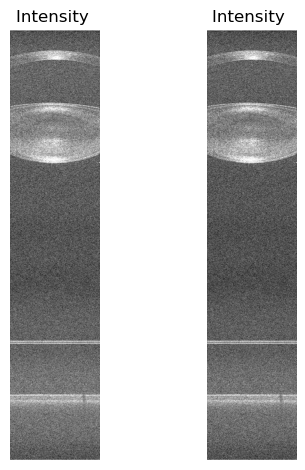

In [39]:
intensity_log = np.log1p(intensity)  # log(1 + x)
low, high = np.percentile(intensity_log, (1, 99))
intensity_log_norm = np.clip((intensity_log - low) / (high - low), 0, 1)

cv2.imwrite("/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/intensity_log.png", (intensity_log_norm * 255).astype(np.uint8))

plt.subplot(1,3,1)
plt.title("Intensity ")
plt.imshow(intensity_log_norm, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Intensity ")
plt.imshow(intensity2, cmap="gray")
# plt.colorbar()
plt.axis("off")

# plt.subplot(1,3,3)
# plt.title("Segmentation Mask")
# plt.imshow(interns, cmap="tab20")  # colorful labels
# # plt.axis("off")

plt.tight_layout()
plt.show()

height, width: 1400 850
unique values in mask: (array([0], dtype=uint8), array([1190000]))
x_start: 10, x_end: 833
unique values in mask: (array([0, 1, 2, 3], dtype=uint8), array([710139,  75273, 223865, 180723]))


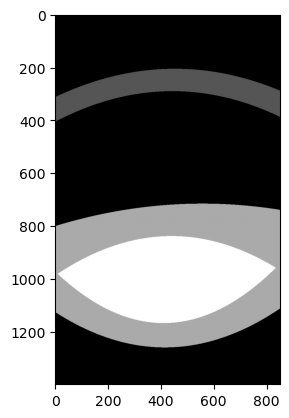

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2

H, W = 4096, 850

data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training Data" 

segmentation = np.fromfile(data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Segmentation.bin", dtype = np.uint8)
# segmentation = np.fromfile("/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/ROC/CN029_FK_24_M/OS/6-0D/6/Vertical/Segmentation.bin", dtype=np.uint8)
# print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

segmentation = segmentation[:H*W].reshape(W, H).T
segmentation = segmentation[:1400, :850]

binary_image = (segmentation == 255).astype(np.uint8)
# print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

height, width = binary_image.shape
print('height, width:', height, width)
mask = np.zeros((height, width), np.uint8)
print('unique values in mask:', np.unique(mask, return_counts = True))
# ---- Layer pairs for segmentation ----
layer_pairs = {
    1 :(2, 3),  # Cornea
    2 :(4, 7),  # Lens
    3 :(5, 6)   # Nucleus
}

all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

def compute_x_range(layer_index):
    first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
    last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

    x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
    x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

    print(f"x_start: {x_start}, x_end: {x_end}")
    # print(f'first_200: {first_200}, last_200: {last_200}')

    return x_start, x_end

# def compute_y6_range(layer_index):
#     first_200_y6 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
#     last_200_y6 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

#     x_y6_start = min(first_200_y6, key=lambda item: item[1])[0] if first_200_y6 else 0
#     x_y6_end = min(last_200_y6, key=lambda item: item[1])[0] if last_200_y6 else 0

#     print(f"x_y6_start: {x_y6_start}, x_y6_end: {x_y6_end}")
#     # print(f'firsty6_200: {first_200_y6}, lasty6_200: {last_200_y6}')

#     return x_y6_start, x_y6_end

x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)
# x6_start, x6_end = compute_y6_range(5) # 6th layer (nucleus bottom)

for x in range(width):
    ys = all_layers[x]
    if len(ys) == 0:
        continue
    
    for layer_num, (y_start, y_end) in layer_pairs.items():
        if y_start <= len(ys) and y_end <= len(ys):
            y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

            if layer_num == 3:  # Nucleus
                if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                    continue
            # if layer_num == 3:  # Nucleus
            #     if x6_start is None or x6_end is None or not (x6_start + 1 <= x < x6_end):
            #         continue

            label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
            
label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
print('unique values in mask:', np.unique(label, return_counts = True))
plt.imshow(label, cmap='grey')
plt.show()

# plt.imshow(mask2)
# plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2

H, W = 4096, 850

data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training Data" 
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/ROC" 

# png_img = data_root + "/CN054_MP_18_F/OS/6-0/4/Horizontal/Intensity.bin"

png_img = cv2.imread(data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Image.png", cv2.IMREAD_UNCHANGED)
# png_img = cv2.imread(data_root + "/CN038_MM_37_F/OD/0-6D/0/Horizontal/Image.png", cv2.IMREAD_UNCHANGED)
image = png_img[:1400, :850]  # crop to match segmentation size
# image = png_img[:1800, :850] 
segmentation = np.fromfile(data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Segmentation.bin", dtype = np.uint8)
# segmentation = np.fromfile(data_root + "/CN054_MP_18_F/OS/6-0/4/Horizontal/Segmentation.bin", dtype = np.uint8)

# print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

segmentation1 = segmentation[:H*W].reshape(W, H).T
segmentation = segmentation1[:1400, :850]

binary_image = (segmentation == 255).astype(np.uint8)
# print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

height, width = binary_image.shape
# print('height, width:', height, width)
mask = np.zeros((height, width), np.uint8)

# ---- Layer pairs for segmentation ----
layer_pairs = {
    1 :(2, 3),  # Cornea
    2 :(4, 7),  # Lens
    3 :(5, 6)   # Nucleus
}

color_map = {
    0: (0, 0, 0),       # black  - background
    1: (0, 0, 255),     # blue   - segment 1
    2: (0, 255, 0),     # green  - segment 2
    3: (255, 0, 0)      # red    - segment 3
}

all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

def compute_x_range(layer_index):
    first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
    last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

    x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
    x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

    # print(f"x_start: {x_start}, x_end: {x_end}")
    # print(f'first_200: {first_200}, last_200: {last_200}')

    return x_start, x_end


x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)

for x in range(width):
    ys = all_layers[x]
    if len(ys) == 0:
        continue
    
    for layer_num, (y_start, y_end) in layer_pairs.items():
        if y_start <= len(ys) and y_end <= len(ys):
            y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

            if layer_num == 3:  # Nucleus
                if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                    continue

            label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
          

label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
# color_mask = cv2.applyColorMap((label*10 ).astype(np.uint8), cv2.COLORMAP_JET)

color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
for k, color in color_map.items():
    color_label[label == k] = color

overlay = cv2.addWeighted(image, 0.6, color_label, 0.4, 0)

plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 4, 2)
plt.title("Binary Image")
plt.imshow(binary_image, cmap="gray")

plt.subplot(1, 4, 3)
plt.title("Overlay Image")
plt.imshow(overlay)

plt.subplot(1, 4, 4)
plt.title("Label Image")
plt.imshow(label, cmap='grey')
plt.show()


[ WARN:0@0.019] global loadsave.cpp:241 findDecoder imread_('/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training Data/CN029_FK_24_M/OS/6-0D/0/Horizontal/Image.png'): can't open/read file: check file path/integrity


TypeError: 'NoneType' object is not subscriptable

In [5]:
def resize_with_padding(img, target_size=(512, 512)):
    h, w = img.shape[:2]
    th, tw = target_size

    # Scale while keeping aspect ratio
    scale = min(tw / w, th / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # Pad to target size
    pad_w = (tw - new_w) // 2
    pad_h = (th - new_h) // 2
    padded = cv2.copyMakeBorder(resized, pad_h, th-new_h-pad_h,
                                pad_w, tw-new_w-pad_w,
                                cv2.BORDER_CONSTANT, value=0)
    # padded = resized
    return padded

In [6]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

print("current working dir:", os.getcwd())

resize = True
# --- Paths ---
data_root = "./dataset"  # root dataset folder
save_images = data_root + "/images"
save_labels = data_root + "/labels"
save_visual = data_root + "/visual"
os.makedirs(save_images, exist_ok=True)
os.makedirs(save_labels, exist_ok=True)
os.makedirs(save_visual, exist_ok=True)


H, W = 4096, 850

data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/Training Data" 

png_img = cv2.imread(data_root + "/CN043_DJ_18_M/OD/6-0D/2/Horizontal/Image.png", cv2.IMREAD_UNCHANGED)
image = png_img[:1400, :850]  # crop to match segmentation size

segmentation = np.fromfile(data_root + "/CN043_DJ_18_M/OD/6-0D/2/Horizontal/Segmentation.bin", dtype = np.uint8)

# print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

segmentation = segmentation[:H*W].reshape(W, H).T
segmentation = segmentation[:1400, :850]

binary_image = (segmentation == 255).astype(np.uint8)
# print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

height, width = binary_image.shape
# print('height, width:', height, width)
mask = np.zeros((height, width), np.uint8)

# ---- Layer pairs for segmentation ----
layer_pairs = {
    1 :(2, 3),  # Cornea
    2 :(4, 7),  # Lens
    3 :(5, 6)   # Nucleus
}

color_map = {
    0: (0, 0, 0),       # black  - background
    1: (0, 0, 255),     # blue   - segment 1
    2: (0, 255, 0),     # green  - segment 2
    3: (255, 0, 0)      # red    - segment 3
}

all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

def compute_x_range(layer_index):
    first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
    last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

    x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
    x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

    # print(f"x_start: {x_start}, x_end: {x_end}")
    # print(f'first_200: {first_200}, last_200: {last_200}')

    return x_start, x_end


x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)

for x in range(width):
    ys = all_layers[x]
    if len(ys) == 0:
        continue
    
    for layer_num, (y_start, y_end) in layer_pairs.items():
        if y_start <= len(ys) and y_end <= len(ys):
            y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

            if layer_num == 3:  # Nucleus
                if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                    continue

            label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
          

label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
# color_mask = cv2.applyColorMap((label*10 ).astype(np.uint8), cv2.COLORMAP_JET)

color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
for k, color in color_map.items():
    color_label[label == k] = color

if resize:
    image = resize_with_padding(image, target_size=(512, 512))
    label = resize_with_padding(label, target_size=(512, 512))
    color_label = resize_with_padding(color_label, target_size=(512, 512))

cv2.imwrite(os.path.join(save_images, f"image.png"), image)
cv2.imwrite(os.path.join(save_labels, f"label.png"), label)
np.save(os.path.join(save_labels, f"label.npy"), label)
cv2.imwrite(os.path.join(save_visual, f"visual.png"), color_label)



current working dir: /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/dataset


True

In [42]:
type= 'bin'
if type =='png':
    print('png')
elif type == 'bin':
    print('bin')

print('pass')

bin
pass


# Annotation

In [5]:
def resize_with_padding(img, target_size=(512, 512)):
    h, w = img.shape[:2]
    th, tw = target_size

    # Scale while keeping aspect ratio
    scale = min(tw / w, th / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # Pad to target size
    pad_w = (tw - new_w) // 2
    pad_h = (th - new_h) // 2
    padded = cv2.copyMakeBorder(resized, pad_h, th-new_h-pad_h,
                                pad_w, tw-new_w-pad_w,
                                cv2.BORDER_CONSTANT, value=0)
    # padded = resized
    return padded

def annotation(image_path, seg_path, resize=True, Dtype = 'bin'):
    # data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/Training Data" 
    H, W = 4096, 850
    if Dtype == 'png':
        png_img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        image = png_img[:1400, :850]  # crop to match segmentation size
    elif Dtype == 'bin':
        intensity = np.fromfile(image_path, dtype=np.float64)
        intensity= intensity[:H*W]
        intensity= intensity.reshape(W, H).T

        low, high = np.percentile(intensity, (1, 99))
        intensity_clipped = np.clip(intensity, low, high)
        intensityc = (intensity_clipped - low) / (high - low)
        image = (intensityc[:1400, :]*255).astype(np.uint8)
    
    segmentation = np.fromfile(seg_path, dtype=np.uint8)

    # print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

    segmentation = segmentation[:H*W].reshape(W, H).T
    segmentation = segmentation[:1400, :850]

    binary_image = (segmentation == 255).astype(np.uint8)
    # print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

    height, width = binary_image.shape
    # print('height, width:', height, width)
    mask = np.zeros((height, width), np.uint8)

    # ---- Layer pairs for segmentation ----
    layer_pairs = {
        1 :(2, 3),  # Cornea
        2 :(4, 7),  # Lens
        3 :(5, 6)   # Nucleus
    }

    color_map = {
        0: (0, 0, 0),       # black  - background
        1: (0, 0, 255),     # blue   - segment 1
        2: (0, 255, 0),     # green  - segment 2
        3: (255, 0, 0)      # red    - segment 3
    }

    all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

    def compute_x_range(layer_index):
        first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
        last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

        x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
        x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

        # print(f"x_start: {x_start}, x_end: {x_end}")
        # print(f'first_200: {first_200}, last_200: {last_200}')

        return x_start, x_end


    x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)

    for x in range(width):
        ys = all_layers[x]
        if len(ys) == 0:
            continue
        
        for layer_num, (y_start, y_end) in layer_pairs.items():
            if y_start <= len(ys) and y_end <= len(ys):
                y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

                if layer_num == 3:  # Nucleus
                    if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                        continue
                   

                label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
            

    label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    # color_mask = cv2.applyColorMap((label*10 ).astype(np.uint8), cv2.COLORMAP_JET)

    color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for k, color in color_map.items():
        color_label[label == k] = color

    if resize:
        image = resize_with_padding(image, target_size=(512, 512))
        label = resize_with_padding(label, target_size=(512, 512))
        color_label = resize_with_padding(color_label, target_size=(512, 512))
    return image, label, color_label

(512, 512, 3)


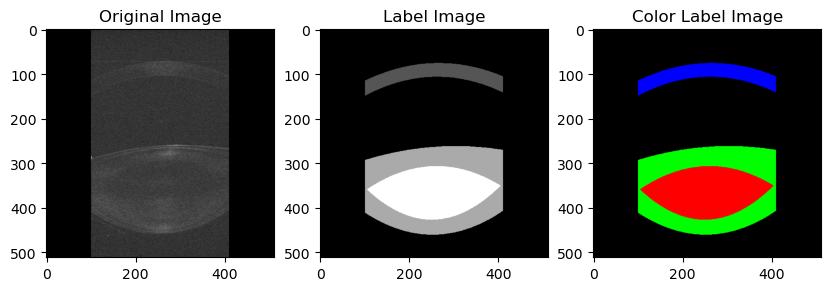

In [19]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data" 

png_img = data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Image.png"
segmentation = data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Segmentation.bin"

image, label, color_label = annotation(png_img, segmentation, resize=True, Dtype='png')
# print(np.min(image), np.max(image), np.unique(image))
print(image.shape)
plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')   
plt.subplot(1, 3, 2)
plt.title("Label Image")
plt.imshow(label, cmap='grey')
plt.subplot(1, 3, 3)
plt.title("Color Label Image")
plt.imshow(color_label)
plt.show()

In [59]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# --- paths ---
# main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/Training Data"
main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/ROC"
data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset" # root dataset folder


save_images = data_root + "/images"
save_labels = data_root + "/labels"
save_visual = data_root + "/visual"
os.makedirs(save_images, exist_ok=True)
os.makedirs(save_labels, exist_ok=True)
os.makedirs(save_visual, exist_ok=True)

# --- recursively loop through all directories ---
for root, dirs, files in os.walk(main_dir):
    if "Segmentation.bin" in files and "Image.png" in files:
        seg_path = os.path.join(root, "Segmentation.bin")
        # img_path = os.path.join(root, "Image.png")
        # if not os.path.exists(img_path):
        img_path = os.path.join(root, "Intensity.bin")

        # --- build a clean unique name ---
        rel_path = os.path.relpath(root, main_dir)  # relative path
        parts = rel_path.split(os.sep)
        # e.g. ['CN043_DJ_18_M', 'OD', '6-0D', '6', 'Horizontal']
        if len(parts) >= 5:
            base_name = f"{parts[0]}_{parts[1]}_{parts[2]}_{parts[3]}_{parts[4]}"
        else:
            base_name = "_".join(parts)


        image, label, color_label = annotation(img_path, seg_path, resize=False, Dtype='bin')

        # --- save outputs ---
        img_out = os.path.join(save_images, f"{base_name}.png")
        lbl_out = os.path.join(save_labels, f"{base_name}.png")
        vis_out = os.path.join(save_visual, f"{base_name}.png")

        cv2.imwrite(img_out, image)
        cv2.imwrite(lbl_out, label)
        cv2.imwrite(vis_out, color_label)

        # print(f"✅ Saved {base_name}")


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- paths ---
# main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data"
# data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512"  # root dataset folder

main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/raw data"
data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/dataset"  # root dataset folder

save_images = os.path.join(data_root, "images")
save_labels = os.path.join(data_root, "labels")
save_visual = os.path.join(data_root, "visual")

os.makedirs(save_images, exist_ok=True)
os.makedirs(save_labels, exist_ok=True)
os.makedirs(save_visual, exist_ok=True)

# --- function for single sample processing ---
def process_sample(root):
    try:
        seg_path = os.path.join(root, "Segmentation.bin")
        img_path = os.path.join(root, "Image.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(root, "Intensity.bin")

        # --- build clean unique name ---
        rel_path = os.path.relpath(root, main_dir)
        parts = rel_path.split(os.sep)
        base_name = "_".join(parts[:5]) if len(parts) >= 5 else "_".join(parts)

        img_out = os.path.join(save_images, f"{base_name}.png")
        lbl_out = os.path.join(save_labels, f"{base_name}.png")
        vis_out = os.path.join(save_visual, f"{base_name}.png")

        # --- skip if already processed ---
        if os.path.exists(lbl_out) and os.path.exists(vis_out):
            return f"⏩ Skipped {base_name}"

        # --- run your annotation function ---
        image, label, color_label = annotation(img_path, seg_path, resize=True, Dtype='png')

        # --- save outputs ---
        cv2.imwrite(img_out, image)
        cv2.imwrite(lbl_out, label)
        cv2.imwrite(vis_out, color_label)

        return f"✅ Saved {base_name}"

    except Exception as e:
        return f"❌ Error in {root}: {str(e)}"


# --- collect all folders that contain required files ---
all_folders = []
for root, dirs, files in os.walk(main_dir):
    if "Segmentation.bin" in files and "Intensity.bin" or "Image.png" in files:
        all_folders.append(root)

print(f"📁 Found {len(all_folders)} valid samples to process.\n")

# --- toggle for parallel execution ---
use_parallel = True  # set to False for debugging

if use_parallel:
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = {executor.submit(process_sample, folder): folder for folder in all_folders}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            print(future.result())
else:
    for folder in tqdm(all_folders, desc="Processing"):
        print(process_sample(folder))

print("\n✅ All done.")


In [ ]:
import os
import shutil
import random

# Paths
root = '/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512'  # Replace with your root path
images_dir = os.path.join('/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/images')   #(root, 'images_all')  # All images in one folder
labels_dir = os.path.join('/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/labels')   #(root, 'labels_all')  # All GTs in one folder
visual_dir = os.path.join('/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/visual')   #(root, 'visual')  # All visualizations in one folder

print("Images source:", images_dir)
print("Labels source:", labels_dir)
print("Visual source:", visual_dir)
import os
import shutil
import random
from glob import glob

# Output structure
for sub in ["images/train", "images/val", "labels/train", "labels/val", "visual/train", "visual/val"]:
    os.makedirs(os.path.join(root, sub), exist_ok=True)

# Collect all images
image_files = glob(os.path.join(images_dir, "*.png"))

# Shuffle for random split
random.seed(42)
random.shuffle(image_files)

# Train/val split (80/20)
split_idx = int(0.7 * len(image_files))
train_images = image_files[:split_idx]
val_images = image_files[split_idx:]

def copy_pairs(image_list, split):
    for img_path in image_list:
        img_name = os.path.basename(img_path)
     
        # Derive label name from image name
        # Example: CN038_..._Vertical_leftImg8bit.png
        # Label:  CN038_..._Vertical_gtFine_labelIds.png
        base_name = img_name    #.replace("leftImg8bit", "gtFine_labelIds")
        label_path = os.path.join(labels_dir, base_name)
        visual_path = os.path.join(visual_dir, base_name)

        # image_name2 = img_name.replace("leftImg8bit", "image")
        # label_name2 = base_name.replace("gtFine_labelIds", "label")
        if not os.path.exists(label_path):
            print(f"[WARN] Label not found for {img_name}")
            continue
        if not os.path.exists(visual_path):
            print(f"[WARN] Visual not found for {img_name}")
            continue
        # Copy image and label
        shutil.copy(img_path, os.path.join(root, f"images/{split}", img_name))
        shutil.copy(label_path, os.path.join(root, f"labels/{split}", base_name))
        shutil.copy(visual_path, os.path.join(root, f"visual/{split}", base_name))

        # shutil.copy(img_path, os.path.join(root, f"images/{split}", 'p'+img_name))
        # shutil.copy(label_path, os.path.join(root, f"labels/{split}", 'p'+base_name))
        # shutil.copy(visual_path, os.path.join(root, f"visual/{split}", 'p'+base_name))

        # shutil.copy(img_path, os.path.join(root, f"images/{split}", image_name2))
        # shutil.copy(label_path, os.path.join(root, f"labels/{split}", label_name2))

# Copy train/val sets
copy_pairs(train_images, "train")
copy_pairs(val_images, "val")

print(f"✅ Done! Train: {len(train_images)} | Val: {len(val_images)}")



Images source: /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/images
Labels source: /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/labels
Visual source: /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/raw/visual
✅ Done! Train: 285 | Val: 123


# Fuzzy label boundary


In [3]:
import numpy as np
import cv2
from scipy.ndimage import gaussian_filter

def add_fuzzy_error(label, 
                    jitter_sigma=2,         # vertical random jitter
                    blur_sigma=1.2,         # blurring of boundary
                    dilation_strength=1):   # optional label thickening
    """
    label: 2D array with values {0,1,2,3} for each layer.
    returns: fuzzy version of the label (same shape)
    """

    h, w = label.shape
    fuzzy = np.zeros_like(label)

    # ---- 1. Generate random jitter per column ----
    jitter = np.random.normal(0, jitter_sigma, size=w).astype(int)
    jitter2 = np.random.normal(0, 5, size=w).astype(int)

    for k in [1, 2, 3]:      # each anatomical layer
        layer_mask = (label == k).astype(np.uint8)

        # apply vertical shift column-wise
        shifted = np.zeros_like(layer_mask)
        # if k ==1:
        #     for x in range(w):
        #         shift = jitter[x]
        #         # shifted[:, x] = layer_mask[:, x]
        #         # print('shift:', shift)
        #         if shift > 0:
        #             shifted[shift:, x] = layer_mask[:-shift, x]
        #         elif shift < 0:
        #             shifted[:shift, x] = layer_mask[-shift:, x]
        # else:
        for x in range(w):
            shift = jitter[x]
            if shift > 0:
                shifted[shift:, x] = layer_mask[:-shift, x]
            elif shift < 0:
                shifted[:shift, x] = layer_mask[-shift:, x]
            else:
                shifted[:, x] = layer_mask[:, x]

        # ---- 2. Blur mask to create a fuzzy boundary ----
        blurred = gaussian_filter(shifted.astype(float), sigma=blur_sigma)

        # ---- 3. Threshold back to binary ----
        fuzzy_layer = (blurred > 0.25).astype(np.uint8)

        # ---- 4. Optional dilation (makes boundary thickness variable) ----
        if dilation_strength > 0:
            kernel = np.ones((dilation_strength, dilation_strength), np.uint8)
            fuzzy_layer = cv2.dilate(fuzzy_layer, kernel, iterations=1)

        # combine into final multi-label output
        fuzzy[fuzzy_layer == 1] = k

    return fuzzy


In [4]:
import numpy as np
import cv2
from scipy.ndimage import gaussian_filter

def elastic_distortion_multilabel(label, alpha=25, sigma=4):
    """
    Applies elastic deformation to a multi-class label image (0,1,2,3).
    
    alpha: magnitude of displacement
    sigma: smoothing applied to the random displacement
    """

    h, w = label.shape
    random_state = np.random.RandomState(None)

    # Generate random displacement fields
    dx = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma) * alpha

    # Create mapping arrays
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = (grid_x + dx).astype(np.float32)
    map_y = (grid_y + dy).astype(np.float32)

    # Apply remapping to each label separately
    warped = np.zeros_like(label)

    for k in np.unique(label):
        mask = (label == k).astype(np.float32)
        warped_mask = cv2.remap(
            mask,
            map_x, map_y,
            interpolation=cv2.INTER_NEAREST,   # nearest keeps labels clean
            borderMode=cv2.BORDER_REFLECT_101
        )
        warped[warped_mask > 0.5] = k

    return warped


In [3]:
import numpy.random as npr

def resize_with_padding(img, target_size=(512, 512)):
    h, w = img.shape[:2]
    th, tw = target_size

    # Scale while keeping aspect ratio
    scale = min(tw / w, th / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # Pad to target size
    pad_w = (tw - new_w) // 2
    pad_h = (th - new_h) // 2
    padded = cv2.copyMakeBorder(resized, pad_h, th-new_h-pad_h,
                                pad_w, tw-new_w-pad_w,
                                cv2.BORDER_CONSTANT, value=0)
    # padded = resized
    return padded

def fuzzy_annotation(image_path, seg_path, resize=True, Dtype = 'bin'):
    # data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/Training Data" 
    H, W = 4096, 850
    if Dtype == 'png':
        png_img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        image = png_img[:1400, :850]  # crop to match segmentation size
    elif Dtype == 'bin':
        intensity = np.fromfile(image_path, dtype=np.float64)
        intensity= intensity[:H*W]
        intensity= intensity.reshape(W, H).T

        low, high = np.percentile(intensity, (1, 99))
        intensity_clipped = np.clip(intensity, low, high)
        intensityc = (intensity_clipped - low) / (high - low)
        image = (intensityc[:1400, :]*255).astype(np.uint8)
    
    segmentation = np.fromfile(seg_path, dtype=np.uint8)

    # print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

    segmentation = segmentation[:H*W].reshape(W, H).T
    segmentation = segmentation[:1400, :850]

    binary_image = (segmentation == 255).astype(np.uint8)
    # print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

    height, width = binary_image.shape
    # print('height, width:', height, width)
    mask = np.zeros((height, width), np.uint8)

    # ---- Layer pairs for segmentation ----
    layer_pairs = {
        1 :(2, 3),  # Cornea
        2 :(4, 7),  # Lens
        3 :(5, 6)   # Nucleus
    }

    color_map = {
        0: (0, 0, 0),       # black  - background
        1: (0, 0, 255),     # blue   - segment 1
        2: (0, 255, 0),     # green  - segment 2
        3: (255, 0, 0)      # red    - segment 3
    }

    all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

    def compute_x_range(layer_index):
        first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
        last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

        x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
        x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

        # print(f"x_start: {x_start}, x_end: {x_end}")
        # print(f'first_200: {first_200}, last_200: {last_200}')

        return x_start, x_end


    x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)

    for x in range(width):
        ys = all_layers[x]
        if len(ys) == 0:
            continue
        fuzzy_sigma = 10  # standard deviation for Gaussian noise
        for layer_num, (y_start, y_end) in layer_pairs.items():
            if y_start <= len(ys) and y_end <= len(ys):
                # y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]
                orig_y_top = ys[y_start - 1]
                orig_y_bottom = ys[y_end - 1]

                # Add fuzzy error (Gaussian noise)
                if x % 1 ==0:
                    # print('fuzzy_sigma:', x)
                    y_top = orig_y_top + int(npr.normal(0, fuzzy_sigma))
                    y_bottom = orig_y_bottom + int(npr.normal(0, fuzzy_sigma))
                else:
                    y_top = orig_y_top
                    y_bottom = orig_y_bottom
                # y_top = gaussian_filter(y_top.astype(float), sigma=2)
                # y_bottom = gaussian_filter(y_bottom.astype(float), sigma=2)
                # Clamp to bounds and ensure y_top < y_bottom
                # y_top = max(0, min(y_top, height - 1))
                # y_bottom = max(0, min(y_bottom, height - 1))
                # if y_top >= y_bottom:
                #     y_top, y_bottom = orig_y_top, orig_y_bottom  # Fallback to original if crossing occurs

                if layer_num == 3:  # Nucleus
                    if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                        continue
                   

                label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
            

    label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    # color_mask = cv2.applyColorMap((label*10 ).astype(np.uint8), cv2.COLORMAP_JET)

    # label = elastic_distortion_multilabel(label, alpha=60, sigma=2)

    # label = add_fuzzy_error(label,
    #                     jitter_sigma=1.0,
    #                     blur_sigma=0.0,
    #                     dilation_strength=0)
    
    color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for k, color in color_map.items():
        color_label[label == k] = color

    if resize:
        image = resize_with_padding(image, target_size=(512, 512))
        label = resize_with_padding(label, target_size=(512, 512))
        color_label = resize_with_padding(color_label, target_size=(512, 512))
    return image, label, color_label

In [1]:
import cv2
import numpy as np
import numpy.random as npr

def fuzzy_annotation22(image_path, seg_path, resize=True, Dtype='bin', max_shift=5):
    """
    Adds global random shift to each layer boundary curve for fuzzy annotations.
    max_shift: maximum absolute shift in pixels (e.g., 5 means -5 to +5)
    """
    H, W = 4096, 850
    if Dtype == 'png':
        png_img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        image = png_img[:1400, :850]
    elif Dtype == 'bin':
        intensity = np.fromfile(image_path, dtype=np.float64)
        intensity = intensity[:H*W].reshape(W, H).T
        low, high = np.percentile(intensity, (1, 99))
        intensity_clipped = np.clip(intensity, low, high)
        intensityc = (intensity_clipped - low) / (high - low)
        image = (intensityc[:1400, :] * 255).astype(np.uint8)
    else:
        raise ValueError("Dtype must be 'png' or 'bin'")

    segmentation = np.fromfile(seg_path, dtype=np.uint8)
    segmentation = segmentation[:H*W].reshape(W, H).T[:1400, :850]

    binary_image = (segmentation == 255).astype(np.uint8)
    height, width = binary_image.shape
    mask = np.zeros((height, width), np.uint8)

    layer_pairs = {
        1: (2, 3),  # Cornea: boundaries 1 and 2 (0-indexed: indices 1,2)
        2: (4, 7),  # Lens
        3: (5, 6)   # Nucleus
    }

    color_map = {
        0: (0, 0, 0),
        1: (0, 0, 255),   # Cornea - blue
        2: (0, 255, 0),   # Lens - green
        3: (255, 0, 0)    # Nucleus - red
    }

    # Extract all raw boundary positions per column
    all_layers = [np.sort(np.where(binary_image[:, x] == 1)[0]) for x in range(width)]

    # Precompute original boundary curves (as arrays of y positions per x)
    boundary_curves = {}  # key: boundary_index (1-based), value: array of y positions (length = width)
    for x in range(width):
        ys = all_layers[x]
        for i in range(len(ys)):
            idx = i + 1  # 1-based as in your original
            if idx not in boundary_curves:
                boundary_curves[idx] = np.full(width, -1, dtype=np.int32)
            if len(ys) > i:
                boundary_curves[idx][x] = ys[i]

    # Generate random global shift for each boundary (independent)
    shifts = {}
    for idx in boundary_curves.keys():
        shifts[idx] = npr.randint(-max_shift, max_shift + 1)

    def compute_x_range(layer_index):
        first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width))
                     if len(all_layers[x]) > layer_index]
        last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width)
                    if len(all_layers[x]) > layer_index]
        x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
        x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0
        return x_start, x_end

    x5_start, x5_end = compute_x_range(4)  # for nucleus restriction

    # Draw shifted lines
    for x in range(width):
        ys = all_layers[x]
        if len(ys) == 0:
            continue

        for layer_num, (y_start_idx, y_end_idx) in layer_pairs.items():
            # Check if both boundaries exist in this column
            if y_start_idx > len(ys) or y_end_idx > len(ys):
                continue

            orig_y_top = ys[y_start_idx - 1]
            orig_y_bottom = ys[y_end_idx - 1]

            # Apply global shift for this boundary
            shift_top = shifts.get(y_start_idx, 0)
            shift_bottom = shifts.get(y_end_idx, 0)

            y_top = orig_y_top + shift_top
            y_bottom = orig_y_bottom + shift_bottom

            # Clamp to image bounds
            y_top = np.clip(y_top, 0, height - 1)
            y_bottom = np.clip(y_bottom, 0, height - 1)

            # Prevent inversion (top should be above bottom)
            if y_top >= y_bottom:
                # Fallback: keep original or minimally adjust
                y_top, y_bottom = orig_y_top, orig_y_bottom

            # Nucleus restriction
            if layer_num == 3:
                if not (x5_start + 1 <= x <= x5_end - 1):
                    continue

            cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)

    # Post-processing
    label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    # label = add_fuzzy_error(label,
    #                     jitter_sigma=4.0,
    #                     blur_sigma=3.0,
    #                     dilation_strength=0)

    color_label = np.zeros((height, width, 3), dtype=np.uint8)
    for k, color in color_map.items():
        color_label[label == k] = color

    if resize:
        image = resize_with_padding(image, target_size=(512, 512))
        label = resize_with_padding(label, target_size=(512, 512))
        color_label = resize_with_padding(color_label, target_size=(512, 512))

    return image, label, color_label

In [ ]:
import numpy.random as npr  # For random noise
fuzzy_sigma=2
w = 50
orig_y_top = np.random.randint(100, 105, size=w).astype(float)
y_top = np.zeros_like(orig_y_top)
for i in range(w):
    y_top[i] = orig_y_top[i] + int(npr.normal(0, fuzzy_sigma))
    # print(f"Original y_top: {orig_y_top[i]}, Fuzzy y_top: {y_top[i]}")
# y_bottom = orig_y_bottom + int(npr.normal(0, fuzzy_sigma))

print('shape of orig_y_top:', orig_y_top.shape)
print('shape of y_top:', y_top.shape)
y_top = gaussian_filter(y_top, sigma=4)#.astype(float)
# y_top = np.clip(y_top, 100, 200).astype(int)

plt.figure(figsize=(10, 5))
plt.plot(orig_y_top, label='Original y_top', color='blue')
plt.plot(y_top, label='Fuzzy y_top', color='red')
plt.legend()
plt.show()

Changed pixels: 4162
Percent changed: 1.59%
IOU class 1: 0.8516636779386667
IOU class 2: 0.9151374690165999
IOU class 3: 0.9597179008106319
(512, 512, 3)


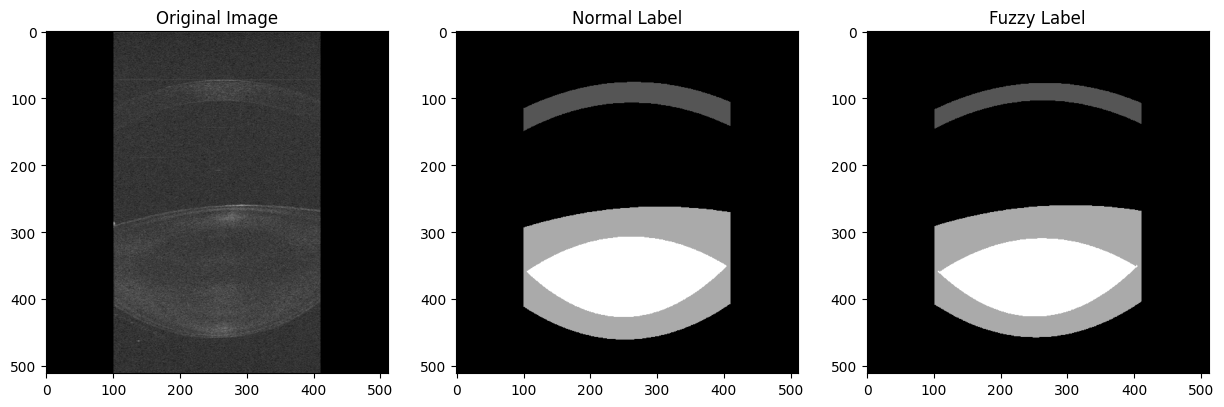

In [9]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data" 
data_root ="D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\old data\Raw Data"

png_img = data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Image.png"
segmentation = data_root + "/CN029_FK_24_M/OS/6-0D/0/Horizontal/Segmentation.bin"

# image, fuzzy_label, color_label = fuzzy_annotation(png_img, segmentation, resize=True, Dtype='png')
image, fuzzy_label, color_label = fuzzy_annotation22(png_img, segmentation, resize=True, Dtype='png', max_shift=10)

image1, normal_label, color_label1 = annotation(png_img, segmentation, resize=True, Dtype='png')

changed = np.sum(normal_label != fuzzy_label)
total = normal_label.size
percent = changed / total * 100

print("Changed pixels:", changed)
print("Percent changed: {:.2f}%".format(percent))
def iou_class(a, b, cls):
    A = (a == cls)
    B = (b == cls)
    intersection = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()
    return intersection / (union + 1e-6)

for cls in [1,2,3]:
    print(f"IOU class {cls}:", iou_class(normal_label, fuzzy_label, cls))

# print(np.min(image), np.max(image), np.unique(image))
print(image.shape)
plt.figure(figsize=(15, 8))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')   
plt.subplot(1, 3, 2)
plt.title("Normal Label")
plt.imshow(normal_label, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Fuzzy Label")
plt.imshow(fuzzy_label, cmap='gray')
plt.show()

[0 1 2 3]
5.517925262451172 37.077941547835586
Changed pixels: 5680
Percent changed: 2.17%


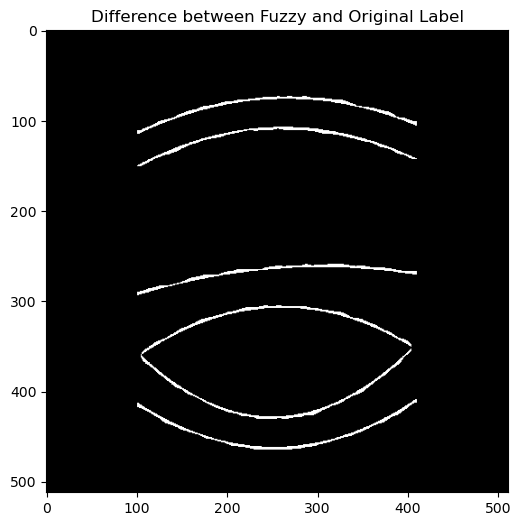

In [125]:
dif= normal_label - fuzzy_label
print(np.unique(normal_label))

print(np.mean(dif), np.std(dif))

changed = np.sum(normal_label != fuzzy_label)
total = normal_label.size
percent = changed / total * 100

print("Changed pixels:", changed)
print("Percent changed: {:.2f}%".format(percent))


diff = (normal_label != fuzzy_label).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.title("Difference between Fuzzy and Original Label")
plt.imshow(diff, cmap='gray')
plt.show()


In [126]:
def iou_class(a, b, cls):
    A = (a == cls)
    B = (b == cls)
    intersection = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()
    return intersection / (union + 1e-6)

for cls in [1,2,3]:
    print(f"IOU class {cls}:", iou_class(normal_label, fuzzy_label, cls))


IOU class 1: 0.8414082145145508
IOU class 2: 0.8807530063312738
IOU class 3: 0.9276862684372041


In [253]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- paths ---
# main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data"
# data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512"  # root dataset folder
# data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/fuzzy_labels"  # root dataset folder

main_dir = "D:\\PG_Gdansk\\Torun_secondment\\Experiments\\dataset_eye\\old data\\Raw Data"
data_root = "D:\\PG_Gdansk\\Torun_secondment\\Experiments\\dataset_eye\\old data\\data_distribution\\fuzzy_data2"

save_images = os.path.join(data_root, "images")
save_labels = os.path.join(data_root, "labels")
save_visual = os.path.join(data_root, "visual")

os.makedirs(save_images, exist_ok=True)
os.makedirs(save_labels, exist_ok=True)
os.makedirs(save_visual, exist_ok=True)

# --- function for single sample processing ---
def process_sample(root):
    try:
        seg_path = os.path.join(root, "Segmentation.bin")
        img_path = os.path.join(root, "Image.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(root, "Intensity.bin")

        # --- build clean unique name ---
        rel_path = os.path.relpath(root, main_dir)
        parts = rel_path.split(os.sep)
        base_name = "_".join(parts[:5]) if len(parts) >= 5 else "_".join(parts)

        img_out = os.path.join(save_images, f"{base_name}.png")
        lbl_out = os.path.join(save_labels, f"{base_name}.png")
        vis_out = os.path.join(save_visual, f"{base_name}.png")

        # --- skip if already processed ---
        if os.path.exists(lbl_out) and os.path.exists(vis_out):
            return f"⏩ Skipped {base_name}"

        # --- run your annotation function ---
        image, label, color_label = fuzzy_annotation22(img_path, seg_path, resize=True, Dtype='png')

        # --- save outputs ---
        cv2.imwrite(img_out, image)
        cv2.imwrite(lbl_out, label)
        cv2.imwrite(vis_out, color_label)

        return f"✅ Saved {base_name}"

    except Exception as e:
        return f"❌ Error in {root}: {str(e)}"


# --- collect all folders that contain required files ---
all_folders = []
for root, dirs, files in os.walk(main_dir):
    if "Segmentation.bin" in files and "Intensity.bin" or "Image.png" in files:
        all_folders.append(root)

print(f"📁 Found {len(all_folders)} valid samples to process.\n")

# --- toggle for parallel execution ---
use_parallel = True  # set to False for debugging

if use_parallel:
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = {executor.submit(process_sample, folder): folder for folder in all_folders}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            print(future.result())
else:
    for folder in tqdm(all_folders, desc="Processing"):
        print(process_sample(folder))

print("\n✅ All done.")


📁 Found 408 valid samples to process.



Processing:   0%|          | 1/408 [00:02<14:28,  2.13s/it]

✅ Saved CN029_FK_24_M_OS_6-0D_0_Horizontal


Processing:   0%|          | 2/408 [00:02<06:52,  1.02s/it]

✅ Saved CN030_BA_19_M_OD_0-6D_4_Horizontal
✅ Saved CN029_FK_24_M_OS_6-0D_0_Vertical
✅ Saved CN029_FK_24_M_OS_6-0D_2_Horizontal
✅ Saved CN029_FK_24_M_OS_6-0D_6_Vertical
✅ Saved CN030_BA_19_M_OD_0-6D_4_Vertical
✅ Saved CN029_FK_24_M_OS_6-0D_4_Vertical


...

✅ Saved CN068_IB_29_F_OS_6-0_6_Vertical
✅ Saved CN068_IB_29_F_OS_6-0_4_Vertical
✅ Saved CN068_IB_29_F_OS_6-0_0_Vertical
✅ Saved CN069_JU_28_M_OS_0-6_2_Vertical
✅ Saved CN069_JU_28_M_OS_0-6_0_Horizontal
✅ Saved CN069_JU_28_M_OS_0-6_0_Vertical
✅ Saved CN068_IB_29_F_OS_6-0_2_Vertical
✅ Saved CN068_IB_29_F_OS_6-0_6_Horizontal
✅ Saved CN069_JU_28_M_OS_0-6_2_Horizontal
✅ Saved CN068_IB_29_F_OS_6-0_2_Horizontal
✅ Saved CN069_JU_28_M_OS_0-6_4_Horizontal


Processing:  98%|█████████▊| 400/408 [00:51<00:00, 14.30it/s]

✅ Saved CN068_IB_29_F_OS_6-0_4_Horizontal
✅ Saved CN069_JU_28_M_OS_0-6_4_Vertical
✅ Saved CN069_JU_28_M_OS_0-6_6_Horizontal
✅ Saved CN069_JU_28_M_OS_6-0_0_Horizontal
✅ Saved CN069_JU_28_M_OS_0-6_6_Vertical


Processing: 100%|██████████| 408/408 [00:51<00:00,  7.87it/s]

✅ Saved CN069_JU_28_M_OS_6-0_0_Vertical
✅ Saved CN069_JU_28_M_OS_6-0_4_Horizontal
✅ Saved CN069_JU_28_M_OS_6-0_2_Horizontal
✅ Saved CN069_JU_28_M_OS_6-0_2_Vertical
✅ Saved CN069_JU_28_M_OS_6-0_6_Horizontal
✅ Saved CN069_JU_28_M_OS_6-0_4_Vertical
✅ Saved CN069_JU_28_M_OS_6-0_6_Vertical

✅ All done.


# only process Images


In [5]:
def annotation2(image_path, resize=True, Dtype = 'bin'):
    # data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/Training Data" 
    H, W = 4096, 850
    if Dtype == 'png':
        png_img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        image = png_img[:1400, :850]  # crop to match segmentation size
    elif Dtype == 'bin':
        intensity = np.fromfile(image_path, dtype=np.float64)
        intensity= intensity[:H*W]
        intensity= intensity.reshape(W, H).T

        low, high = np.percentile(intensity, (1, 99))
        intensity_clipped = np.clip(intensity, low, high)
        intensityc = (intensity_clipped - low) / (high - low)
        image = (intensityc[:1400, :]*255).astype(np.uint8)
    
    # segmentation = np.fromfile(seg_path, dtype=np.uint8)

    # # print('unique values in segmentation:', np.unique(segmentation, return_counts = True))

    # segmentation = segmentation[:H*W].reshape(W, H).T
    # segmentation = segmentation[:1400, :850]

    # binary_image = (segmentation == 255).astype(np.uint8)
    # # print('unique values in binary_image:', np.unique(binary_image, return_counts = True))

    # height, width = binary_image.shape
    # # print('height, width:', height, width)
    # mask = np.zeros((height, width), np.uint8)

    # # ---- Layer pairs for segmentation ----
    # layer_pairs = {
    #     1 :(2, 3),  # Cornea
    #     2 :(4, 7),  # Lens
    #     3 :(5, 6)   # Nucleus
    # }

    # color_map = {
    #     0: (0, 0, 0),       # black  - background
    #     1: (0, 0, 255),     # blue   - segment 1
    #     2: (0, 255, 0),     # green  - segment 2
    #     3: (255, 0, 0)      # red    - segment 3
    # }

    # all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

    # def compute_x_range(layer_index):
    #     first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
    #     last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

    #     x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
    #     x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

    #     # print(f"x_start: {x_start}, x_end: {x_end}")
    #     # print(f'first_200: {first_200}, last_200: {last_200}')

    #     return x_start, x_end


    # x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)

    # for x in range(width):
    #     ys = all_layers[x]
    #     if len(ys) == 0:
    #         continue
        
    #     for layer_num, (y_start, y_end) in layer_pairs.items():
    #         if y_start <= len(ys) and y_end <= len(ys):
    #             y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

    #             if layer_num == 3:  # Nucleus
    #                 if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
    #                     continue
                   

    #             label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
            

    # label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    # # color_mask = cv2.applyColorMap((label*10 ).astype(np.uint8), cv2.COLORMAP_JET)

    # color_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    # for k, color in color_map.items():
    #     color_label[label == k] = color

    if resize:
        image = resize_with_padding(image, target_size=(512, 512))
        # label = resize_with_padding(label, target_size=(512, 512))
        # color_label = resize_with_padding(color_label, target_size=(512, 512))
    return image #, label, color_label

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- paths ---
# main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data"
# data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512"  # root dataset folder

main_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/raw data"
data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/dataset"  # root dataset folder

save_images = os.path.join(data_root, "images")
save_labels = os.path.join(data_root, "labels")
save_visual = os.path.join(data_root, "visual")

os.makedirs(save_images, exist_ok=True)
os.makedirs(save_labels, exist_ok=True)
os.makedirs(save_visual, exist_ok=True)

# --- function for single sample processing ---
def process_sample(root):
    try:
        # seg_path = os.path.join(root, "Segmentation.bin")
        img_path = os.path.join(root, "Image.png")
        # if not os.path.exists(img_path):
        #     img_path = os.path.join(root, "Intensity.bin")

        # --- build clean unique name ---
        rel_path = os.path.relpath(root, main_dir)
        parts = rel_path.split(os.sep)
        base_name = "_".join(parts[:5]) if len(parts) >= 5 else "_".join(parts)

        img_out = os.path.join(save_images, f"{base_name}.png")
        lbl_out = os.path.join(save_labels, f"{base_name}.png")
        vis_out = os.path.join(save_visual, f"{base_name}.png")

        # --- skip if already processed ---
                    # if os.path.exists(lbl_out) and os.path.exists(vis_out):
                    #     return f"⏩ Skipped {base_name}"

        # --- run your annotation function ---
        image = annotation2(img_path, resize=True, Dtype='png')

        # --- save outputs ---
        cv2.imwrite(img_out, image)
        # cv2.imwrite(lbl_out, label)
        # cv2.imwrite(vis_out, color_label)

        return f"✅ Saved {base_name}"

    except Exception as e:
        return f"❌ Error in {root}: {str(e)}"


# --- collect all folders that contain required files ---
all_folders = []
for root, dirs, files in os.walk(main_dir):
    if "Segmentation.bin" in files and "Intensity.bin" or "Image.png" in files:
        all_folders.append(root)

print(f"📁 Found {len(all_folders)} valid samples to process.\n")

# --- toggle for parallel execution ---
use_parallel = True  # set to False for debugging

if use_parallel:
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = {executor.submit(process_sample, folder): folder for folder in all_folders}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            print(future.result())
else:
    for folder in tqdm(all_folders, desc="Processing"):
        print(process_sample(folder))

print("\n✅ All done.")
